# Experiment No 9

## Aim:
To build, train, and evaluate an Artificial Neural Network (ANN) using TensorFlow and Keras to classify the Glass Identification dataset.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

print("--- Step 1 & 2: Load Data, Encode, Split, and Scale ---")

# Load dataset
glass = fetch_ucirepo(id=42)
X = glass.data.features.values
y = glass.data.targets.values.ravel()

# Encode target (multiclass)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

--- Step 1 & 2: Load Data, Encode, Split, and Scale ---
Training Shape: (171, 9)
Testing Shape: (43, 9)


## Step 3 & 4: ANN Architecture & Compilation

In [6]:
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

# Output Layer (multiclass → softmax)
model.add(Dense(len(np.unique(y)), activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350 (1.37 KB)

 Trainable params: 350 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Model Training

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2500 - loss: 1.8090 - val_accuracy: 0.2286 - val_loss: 1.8148
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2353 - loss: 1.7793 - val_accuracy: 0.2286 - val_loss: 1.7862
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2500 - loss: 1.7768 - val_accuracy: 0.2286 - val_loss: 1.7611
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3015 - loss: 1.7501 - val_accuracy: 0.2286 - val_loss: 1.7398
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3309 - loss: 1.7108 - val_accuracy: 0.2286 - val_loss: 1.7200
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3676 - loss: 1.6779 - val_accuracy: 0.2286 - val_loss: 1.7022
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3309 - loss: 1.6179 - val_accuracy: 0.2286 - val_loss: 1.6851
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3603 - loss: 1.5955 - val_accuracy: 0.2286 - val_loss: 1.6678
Epoch 9

## Step 6: Evaluation

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 32.56%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Confusion Matrix:
[[14  0  0  0  0  0]
 [14  0  0  1  0  0]
 [ 3  0  0  0  0  0]
 [ 3  0  0  0  0  0]
 [ 2  0  0  0  0  0]
 [ 4  0  0  2  0  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        14
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         6

    accuracy                           0.33        43
   macro avg       0.06      0.17      0.09        43
weighted avg       0.11      0.33      0.17        43



c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## Accuracy Plot

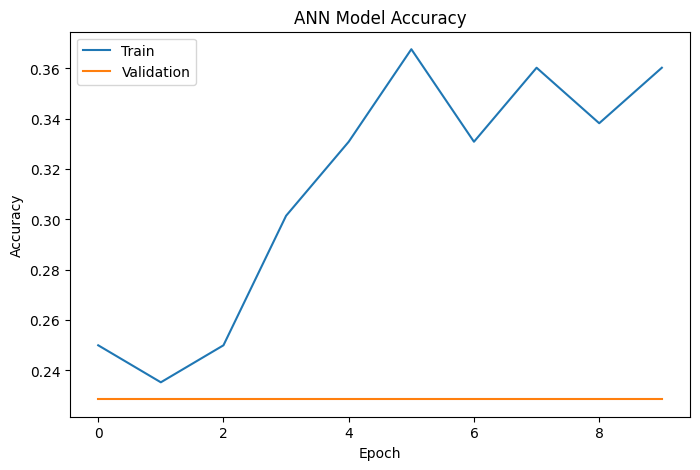

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Conclusion

The Artificial Neural Network successfully classifies different types of glass based on chemical composition. By using multiple hidden layers and nonlinear activation functions, the model captures complex relationships between features. The results demonstrate that ANN is effective for multiclass classification problems like Glass Identification.